In [1]:
import tensorflow as tf
from tensorflow.data import TFRecordDataset 
import numpy as np
import os
import matplotlib.pyplot as plt
from common import fast_gpu_map,SAMPLERATE,feature_description

from model import build_1d_cnn_model
import common


BATCH_SIZE=1
recordfile="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/filtered_poly_data0.tfrecord"
model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5"#"/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5"

cnn_model=build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE,44,training=False)# common.OUTPUT_DIM_NOTES,training=False)
cnn_model.load_weights(model_weights)
dataset=TFRecordDataset(recordfile)
def parse_example(example_proto):
    return tf.io.parse_single_example(example_proto, feature_description)
# Parse the dataset
dataset = dataset.map(parse_example).shuffle(buffer_size=10000,reshuffle_each_iteration=True)
dataset=dataset.map(lambda x: fast_gpu_map(x,training=False)).batch(BATCH_SIZE,drop_remainder=True).take(1000).prefetch(tf.data.AUTOTUNE)
#dataset=dataset.map(lambda path: fast_gpu_map(path, training=False)).take(100).prefetch(tf.data.AUTOTUNE)
#dataset = dataset.shuffle(BATCH_SIZE * 2).map(lambda path: fast_gpu_map(path, training=False), num_parallel_calls=tf.data.AUTOTUNE)
labels_true_all=[]
labels_pred_all=[]
total_tp=0
total_fp=0
total_fn=0
for audio,label in dataset:
    # print("Audio shape:", audio.shape)
    pred=cnn_model.predict(audio,verbose=0)
    # print("Pred shape:", pred.shape)
    # print("Label shape:", label.shape)
    label=label.numpy()#.flatten()
    pred=pred#.flatten()
    # print("flat Pred shape:", pred.shape)
    # print("flat Label shape:", label.shape)
    labels_true_all.append(label)
    labels_pred_all.append(pred)
    thresh=0.5
    label_active = label#[:88] # Assuming 88 notes
    pred_active = pred#[ :88]
    total_tp += np.sum((label_active == 1) & (pred_active > thresh))
    #total_tp+=np.sum((label==1) & (pred>thresh))
    total_fp+=np.sum((label_active==0)&(pred_active>thresh))
    total_fn+=np.sum((label_active==1)&(pred_active<=thresh))

print("Total True Positives:", total_tp)
print("Total False Positives:", total_fp)
print("Total False Negatives:", total_fn)
precision=total_tp/(total_tp+total_fp+1e-8)
recall=total_tp/(total_tp+total_fn+1e-8)
print("Precision:", precision)
print("Recall:", recall)


I0000 00:00:1773162456.730147  200222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773162456.755890  200222 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773162457.337804  200222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1773162458.059862  200222 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel bi

Initial input shape: (1, 148, 512)
After first Conv2D: (1, 74, 64)
Extracting string from filters 0 to 10
String 0 section shape: (1, 10, 64)
String 0 after first Conv1D: (1, 10, 128)
Extracting string from filters 11 to 20
String 11 section shape: (1, 9, 64)
String 11 after first Conv1D: (1, 9, 128)
Extracting string from filters 21 to 30
String 21 section shape: (1, 9, 64)
String 21 after first Conv1D: (1, 9, 128)
Extracting string from filters 31 to 38
String 31 section shape: (1, 7, 64)
String 31 after first Conv1D: (1, 7, 128)
Extracting string from filters 39 to 48
String 39 section shape: (1, 9, 64)
String 39 after first Conv1D: (1, 9, 128)
Extracting string from filters 49 to 73
String 49 section shape: (1, 24, 64)
String 49 after first Conv1D: (1, 24, 128)


I0000 00:00:1773162458.833650  200412 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144
I0000 00:00:1773162459.058037  200337 service.cc:153] XLA service 0x7207ec03d6d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773162459.058055  200337 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5080, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.14.0)
I0000 00:00:1773162459.069189  200337 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773162459.125818  200337 cuda_dnn.cc:461] Loaded cuDNN version 91400
I0000 00:00:1773162460.180384  200337 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Total True Positives: 383
Total False Positives: 70
Total False Negatives: 107
Precision: 0.8454746136678704
Recall: 0.7816326530452727


In [2]:
print("Length of labels_true_all:", len(labels_true_all))
labels_true=np.concatenate(labels_true_all,axis=0)
labels_pred=np.concatenate(labels_pred_all,axis=0)
labels_pred=(labels_pred>0.5).astype(np.float32)
print("Shape of labels true:",labels_true.shape)
#compute recall
tp=np.sum((labels_true==1) & (labels_pred==1),axis=0)

fp=np.sum((labels_true==0)&(labels_pred==1),axis=0)
fn=np.sum((labels_true==1)&(labels_pred==0),axis=0)
print("Shape of tp",tp.shape)

precision=tp/(tp+fp+1e-8)
print("precision:", precision)
recall=tp/(tp+fn+1e-8)
print("recall:", recall)
print("True Positives:", tp)
print("False Positives:", fp)

Length of labels_true_all: 1000
Shape of labels true: (1000, 44)
Shape of tp (44,)
precision: [0.66666666 0.         0.         0.         0.83333333 0.68
 0.         1.         0.75       0.92857143 0.83333333 0.
 0.79487179 1.         1.         0.94594595 1.         0.875
 1.         0.80769231 1.         0.5        1.         0.
 0.89285714 1.         0.66666667 0.5        0.89473684 0.95833333
 0.         1.         0.         1.         1.         0.
 1.         0.         0.         0.         0.         0.
 0.         0.        ]
recall: [0.5        0.         0.         0.         1.         0.85
 0.         0.83333333 0.75       0.86666667 0.67307692 0.
 0.91176471 0.875      0.83333333 0.74468085 0.86666667 0.71428571
 1.         0.63636364 1.         0.25       0.15384615 0.
 0.86206897 1.         0.88888889 0.5        1.         0.82142857
 0.         1.         0.         1.         0.77777778 0.
 1.         0.         0.         0.         0.         0.
 0.         0.   

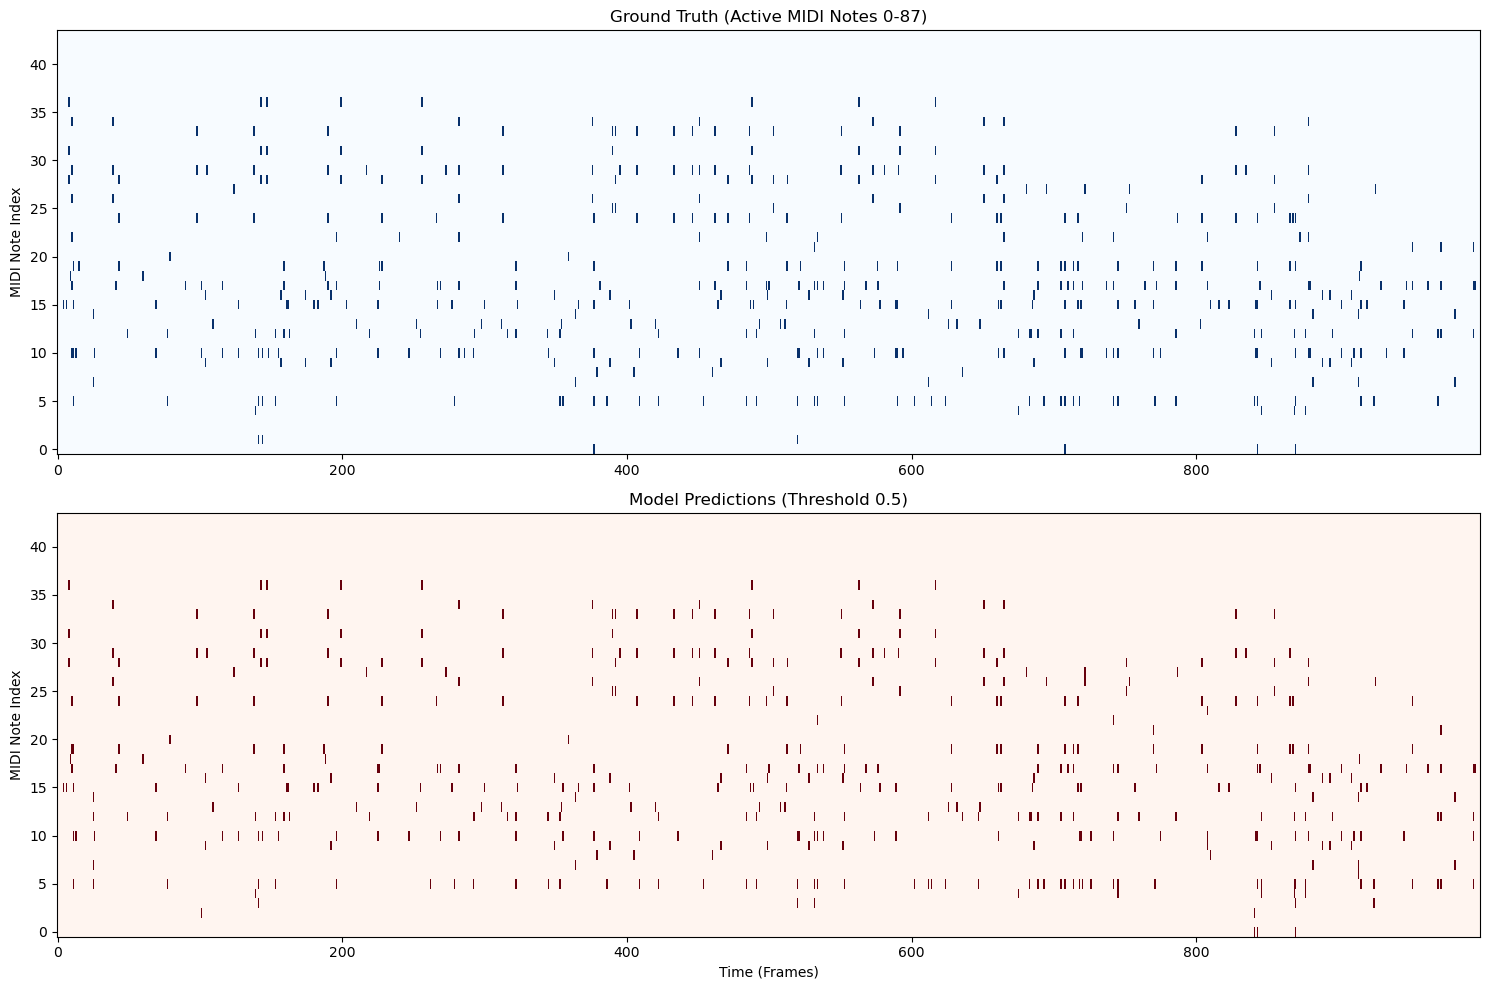

In [3]:
# Convert lists to single arrays
all_true = np.concatenate(labels_true_all, axis=0)[:, :88]
all_pred = np.concatenate(labels_pred_all, axis=0)[:, :88]

# Binary threshold for the plot
all_pred_bin = (all_pred > 0.5).astype(np.float32)

plt.figure(figsize=(15, 10))

# Plot Ground Truth (Blue)
plt.subplot(2, 1, 1)
plt.imshow(all_true.T, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
plt.title("Ground Truth (Active MIDI Notes 0-87)")
plt.ylabel("MIDI Note Index")

# Plot Predictions (Red)
plt.subplot(2, 1, 2)
plt.imshow(all_pred_bin.T, aspect='auto', origin='lower', cmap='Reds', interpolation='nearest')
plt.title("Model Predictions (Threshold 0.5)")
plt.ylabel("MIDI Note Index")
plt.xlabel("Time (Frames)")

plt.tight_layout()
plt.show()